In [96]:
import pandas as pd
import pandas.io.sql as sqlio
import psycopg2 as ps

print("OK, ambiente configurado")



OK, ambiente configurado


In [97]:
conn = ps.connect(
    dbname='tech4',
    user='postgres',
    password='Pfi@213zer',
    host='localhost',
    port='5433'
)


In [98]:
sql = """
SELECT *
FROM analytics.obesity_base
"""


In [99]:
df = sqlio.read_sql_query(sql, conn)


C:\Users\excel\AppData\Local\Temp\ipykernel_27244\1825879229.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = sqlio.read_sql_query(sql, conn)


In [100]:
df.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [101]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [102]:
df.shape


(2111, 17)

In [103]:
# Estatística Básica

In [104]:
df.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [105]:
# Quais tipos de resultados temos na nossa base?

In [106]:
print(f'Tipos de peso: {df.Obesity.unique()}')

Tipos de peso: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [107]:
df_valor = df[['Gender','family_history','Weight']]

In [108]:
df_valor.groupby(['Gender','family_history']).agg(['min','max','mean']).round(2)

Weight               
                         min     max   mean
Gender family_history                      
Female no               39.1   93.00  51.52
       yes              39.0  165.06  91.11
Male   no               45.0  115.00  70.45
       yes              45.0  173.00  94.17

In [109]:
df.family_history.unique()

array(['yes', 'no'], dtype=object)

In [110]:
df.FAVC.unique()

array(['no', 'yes'], dtype=object)

In [111]:
df['obesity_target'] = df['Obesity'].apply(
    lambda x: 1 if x.startswith('Obesity') else 0
)


In [112]:
df.head(20)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,obesity_target
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,0
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,0
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,0
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,0
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,0
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight,0
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight,0
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,0
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight,0
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight,0


In [113]:
df['obesity_target'].value_counts(normalize=True)


obesity_target
0    0.539555
1    0.460445
Name: proportion, dtype: float64

In [114]:
binary_cols = ['family_history', 'FAVC', 'SMOKE', 'SCC']


In [115]:
df[binary_cols] = df[binary_cols].apply(
    lambda x: x.str.lower().str.strip()
)


In [116]:
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


C:\Users\excel\AppData\Local\Temp\ipykernel_27244\2505204152.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


In [117]:
df[binary_cols].info()
df[binary_cols].head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   family_history  2111 non-null   int64
 1   FAVC            2111 non-null   int64
 2   SMOKE           2111 non-null   int64
 3   SCC             2111 non-null   int64
dtypes: int64(4)
memory usage: 66.1 KB


,family_history,FAVC,SMOKE,SCC
0,1,0,0,0
1,1,0,1,1
2,1,0,0,0
3,0,0,0,0
4,0,0,0,0


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib e Seaborn OK")




Matplotlib e Seaborn OK


In [119]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,obesity_target
0,Female,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight,0
1,Female,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,0
2,Male,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,0
3,Male,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I,0
4,Male,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,0


In [120]:
df.drop(['Gender1'], axis=1, inplace=True)

KeyError: "['Gender1'] not found in axis"

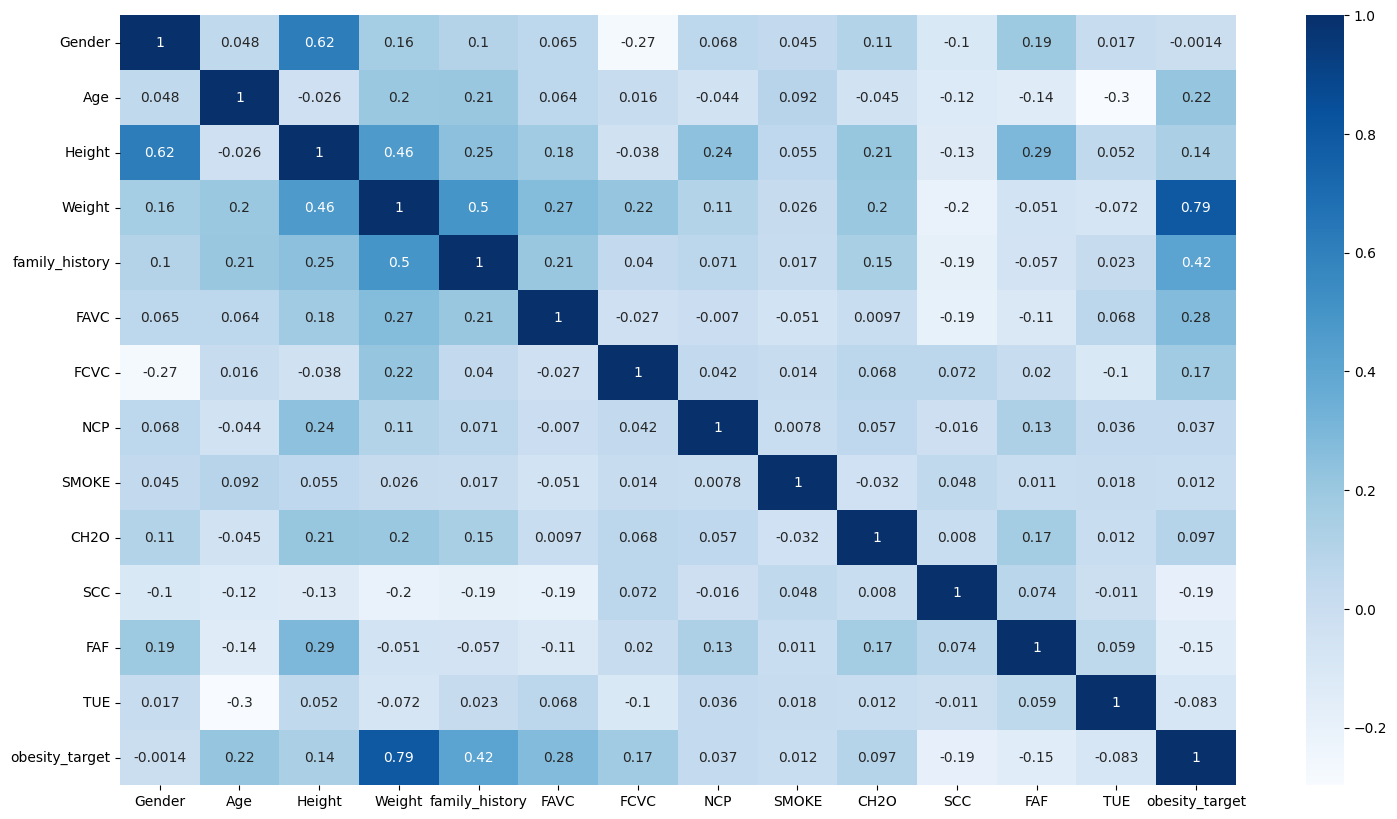

In [ ]:
df_numeric = df.select_dtypes(include='number')
corr = df_numeric.corr()

plt.figure(figsize=(18,10))
sns.heatmap(corr, cmap='Blues', annot=True)
plt.show()


In [ ]:
df.drop(['Weight'], axis=1, inplace=True)

In [ ]:
df['Gender'].value_counts(normalize = True) * 100

Gender
1    50.592136
0    49.407864
Name: proportion, dtype: float64

In [ ]:
df['family_history'].value_counts(normalize = True) * 100

family_history
1    81.762198
0    18.237802
Name: proportion, dtype: float64

In [ ]:
df['FAVC'].value_counts(normalize = True) * 100

FAVC
1    88.394126
0    11.605874
Name: proportion, dtype: float64

In [ ]:
df['CAEC'].value_counts(normalize = True) * 100

CAEC
Sometimes     83.609664
Frequently    11.463761
Always         2.510658
no             2.415917
Name: proportion, dtype: float64

In [ ]:
df['SMOKE'].value_counts(normalize = True) * 100

SMOKE
0    97.91568
1     2.08432
Name: proportion, dtype: float64

In [ ]:
df['SCC'].value_counts(normalize = True) * 100

SCC
0    95.452392
1     4.547608
Name: proportion, dtype: float64

In [ ]:
df['CALC'].value_counts(normalize = True) * 100

CALC
Sometimes     66.366651
no            30.270014
Frequently     3.315964
Always         0.047371
Name: proportion, dtype: float64

In [ ]:
df['MTRANS'].value_counts(normalize = True) * 100

MTRANS
Public_Transportation    74.846045
Automobile               21.648508
Walking                   2.652771
Motorbike                 0.521080
Bike                      0.331596
Name: proportion, dtype: float64

In [ ]:

import matplotlib as mpl
     

In [ ]:
#Configurações dos gráficos:
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.figsize'] = (10,6)

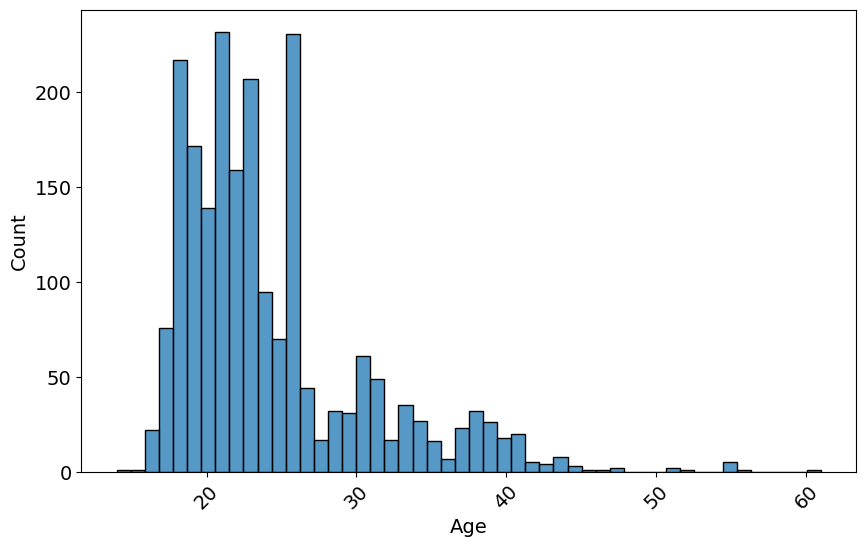

In [ ]:
sns.histplot(data=df, x='Age', bins=50) 
plt.xticks(rotation=45)
plt.show()

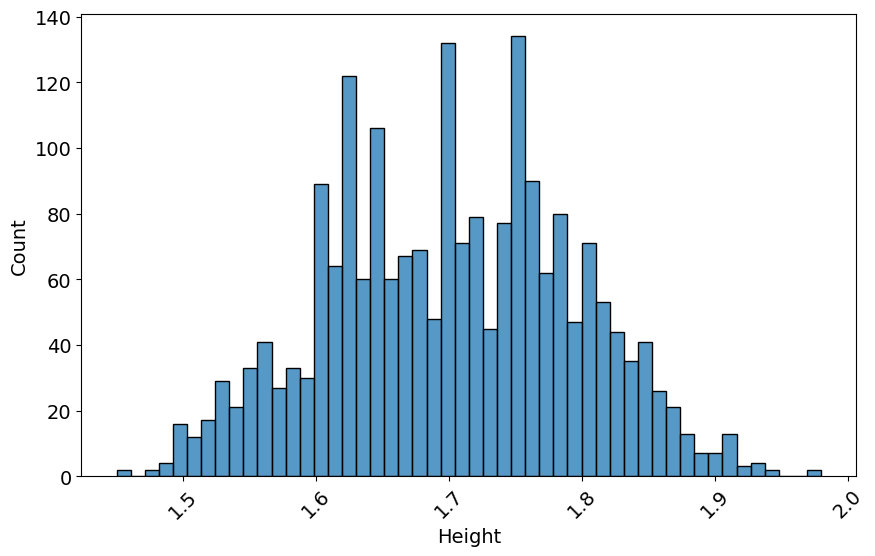

In [ ]:
sns.histplot(data=df, x='Height', bins=50) 
plt.xticks(rotation=45)
plt.show()

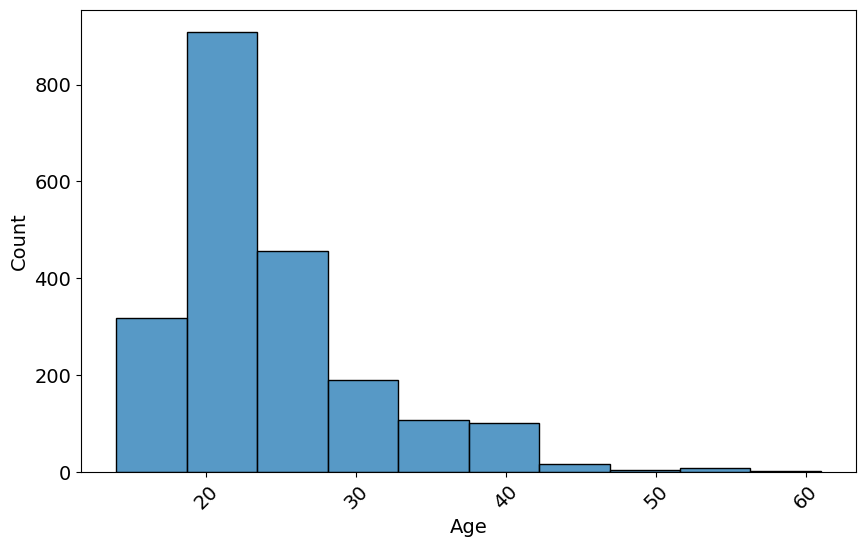

In [ ]:
sns.histplot(data=df, x='Age', bins=10) 
plt.xticks(rotation=45)
plt.show()

# Divisão 1

In [ ]:
import numpy as np

In [ ]:
SEED = 1561651

In [ ]:
print("teste")


     

teste


In [ ]:
import sys
sys.executable



'c:\\Users\\excel\\Documents\\FIAP\\FASE 4 - Data Viz and Production Models\\0. Tech Challenge\\obesity_project\\.venv\\Scripts\\python.exe'

In [ ]:
import sklearn
print(sklearn.__version__)


1.8.0


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
SEED = 1561651

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)

In [ ]:

train_df.shape

(1688, 17)

In [ ]:
test_df.shape
     

(423, 17)

In [ ]:
train_df_copy = train_df.copy()
test_df_copy = test_df.copy()

In [ ]:

train_df.to_csv('train.csv',index=False)

In [ ]:
train_df.to_csv('test.csv',index=False)

In [ ]:
train_df.head()

,Gender,Age,Height,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,obesity_target
526,0,19.869970,1.520997,0,1,3.000000,1.000000,Frequently,0,1.527036,0,0.000000,0.860497,Sometimes,Public_Transportation,Insufficient_Weight,0
979,0,19.774317,1.541039,0,1,2.706134,2.669766,Sometimes,0,1.979848,1,0.445238,0.908836,Sometimes,Public_Transportation,Overweight_Level_I,0
1946,0,23.694840,1.637524,1,1,3.000000,3.000000,Sometimes,0,2.495961,0,0.189831,0.652289,Sometimes,Public_Transportation,Obesity_Type_III,1
2020,0,25.993154,1.609401,1,1,3.000000,3.000000,Sometimes,0,2.613504,0,0.067985,0.778632,Sometimes,Public_Transportation,Obesity_Type_III,1
1935,0,21.412434,1.675562,1,1,3.000000,3.000000,Sometimes,0,1.484938,0,0.742250,0.604692,Sometimes,Public_Transportation,Obesity_Type_III,1


In [ ]:

from sklearn.base import BaseEstimator, TransformerMixin 
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
     

In [ ]:
# Abaixo codio antigo

In [130]:
from sklearn.pipeline import Pipeline
     

In [131]:

def pipeline(df):

    pipeline = Pipeline([
        ('OneHotEncoding', OneHotEncodingNames()),
        ('min_max_scaler', MinMax()),
        ('oversample', Oversample())
    ])
    df_pipeline = pipeline.fit_transform(df)
    return df_pipeline

In [132]:
train = pipeline(train_df)


Uma ou mais features não estão no DataFrame
